In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import SGDRegressor, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_style("whitegrid")


In [ ]:
try:
    from google.colab import files
    print("Upload Train_data.csv and Test_data.csv")
    uploaded = files.upload()
except ImportError:
    print("Not running in Colab -- make sure Train_data.csv / Test_data.csv are in the working directory.")


Upload Train_data.csv and Test_data.csv


Saving Test_data.csv to Test_data.csv
Saving Train_data.csv to Train_data.csv


In [ ]:
df = pd.read_csv("Train_data.csv")
print("Raw shape:", df.shape)
df.head()


Raw shape: (25192, 42)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [ ]:
numeric_check = df.select_dtypes(include="number")
zero_var_cols = [c for c in numeric_check.columns if numeric_check[c].std() == 0]
print("Zero-variance columns found:", zero_var_cols)
print("Null values total:", df.isnull().sum().sum())


Zero-variance columns found: ['num_outbound_cmds', 'is_host_login']
Null values total: 0


In [ ]:
ZERO_VAR_COLS = ["num_outbound_cmds", "is_host_login"]
df = df.drop(columns=ZERO_VAR_COLS)
df = df.drop(columns=["class"])

TARGET = "count"
y = df[TARGET]
X = df.drop(columns=[TARGET])

CATEGORICAL = ["protocol_type", "service", "flag"]
NUMERIC = [c for c in X.columns if c not in CATEGORICAL]

print("Categorical columns (need numeric conversion):", CATEGORICAL)
print("Numeric feature count:", len(NUMERIC))


Categorical columns (need numeric conversion): ['protocol_type', 'service', 'flag']
Numeric feature count: 35


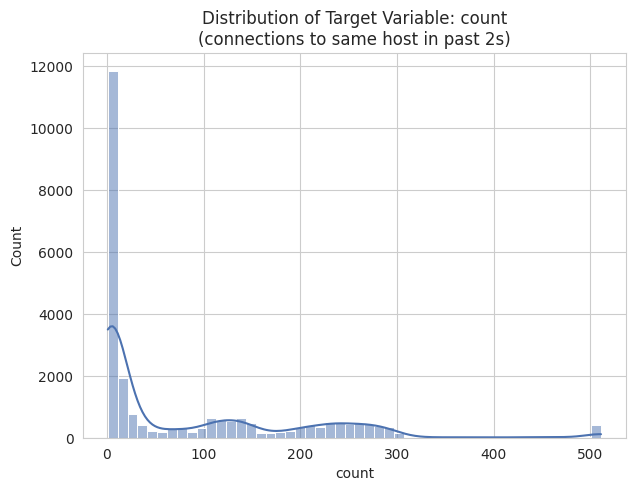

In [ ]:
plt.figure(figsize=(7,5))
sns.histplot(y, bins=50, kde=True, color="#4C72B0")
plt.title("Distribution of Target Variable: count\n(connections to same host in past 2s)")
plt.xlabel("count")
plt.show()

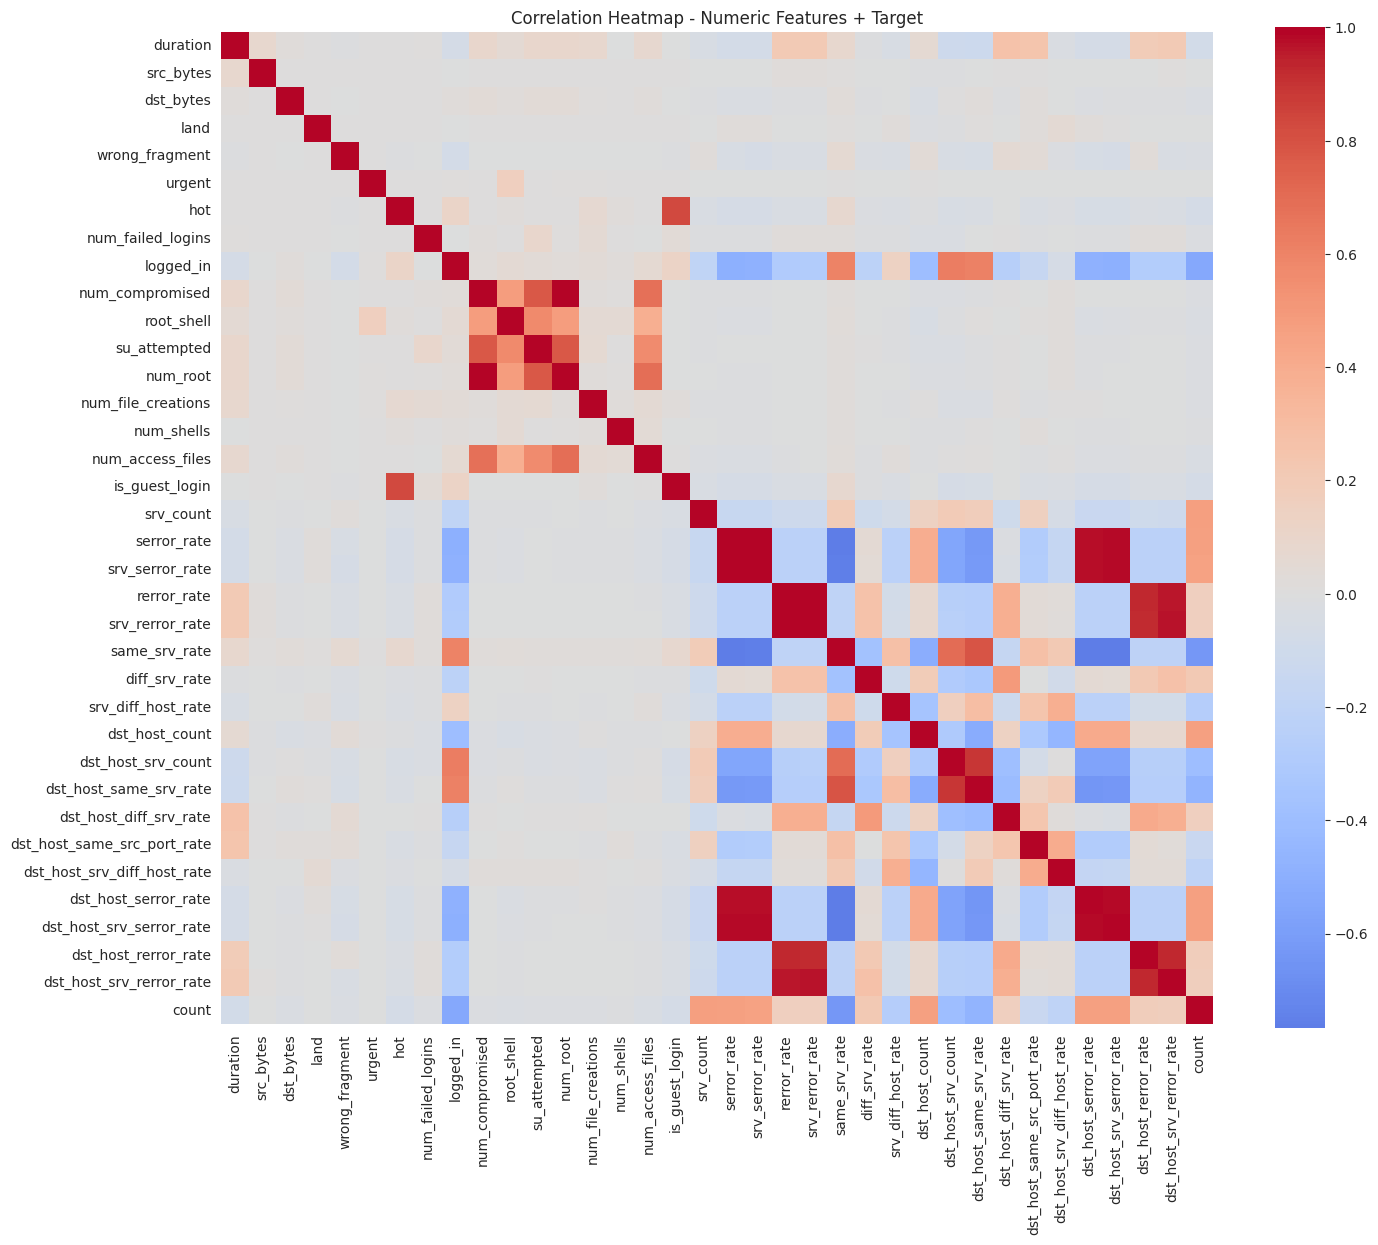

In [ ]:
plt.figure(figsize=(16,13))
corr = df[NUMERIC + [TARGET]].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap - Numeric Features + Target")
plt.show()



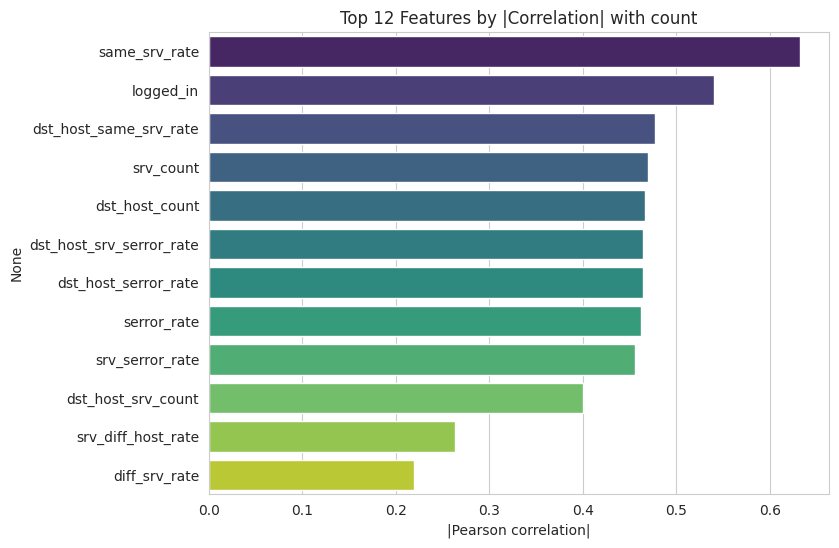

same_srv_rate               0.631890
logged_in                   0.539870
dst_host_same_srv_rate      0.477335
srv_count                   0.469728
dst_host_count              0.466144
dst_host_srv_serror_rate    0.464837
dst_host_serror_rate        0.464305
serror_rate                 0.462505
srv_serror_rate             0.455964
dst_host_srv_count          0.399974
srv_diff_host_rate          0.263691
diff_srv_rate               0.218920
Name: count, dtype: float64


In [ ]:
top_corr = corr[TARGET].drop(TARGET).abs().sort_values(ascending=False).head(12)
plt.figure(figsize=(8,6))
sns.barplot(x=top_corr.values, y=top_corr.index, palette="viridis")
plt.title("Top 12 Features by |Correlation| with count")
plt.xlabel("|Pearson correlation|")
plt.show()
print(top_corr)


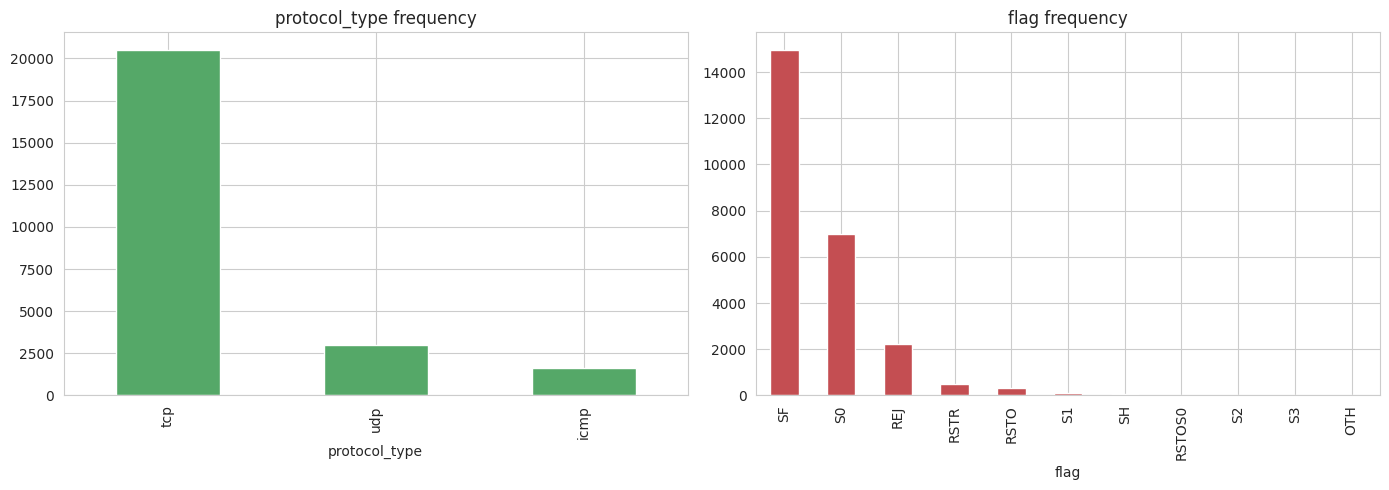

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
X["protocol_type"].value_counts().plot(kind="bar", ax=axes[0], color="#55A868")
axes[0].set_title("protocol_type frequency")
X["flag"].value_counts().plot(kind="bar", ax=axes[1], color="#C44E52")
axes[1].set_title("flag frequency")
plt.tight_layout()
plt.show()

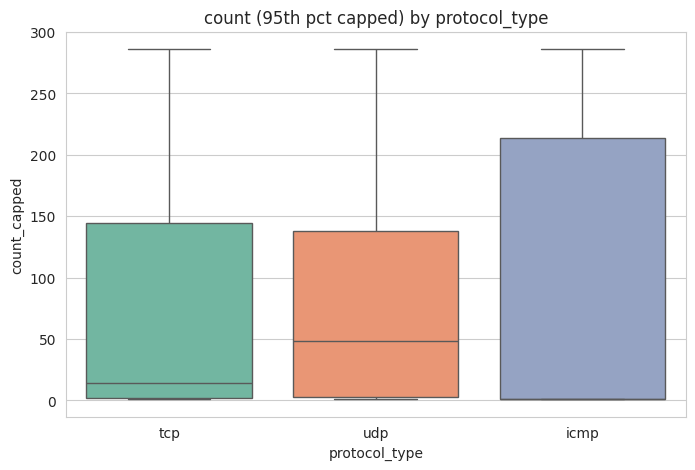

In [ ]:
plot_df = df.copy()
plot_df["count_capped"] = plot_df["count"].clip(upper=plot_df["count"].quantile(0.95))
plt.figure(figsize=(8,5))
sns.boxplot(data=plot_df, x="protocol_type", y="count_capped", palette="Set2")
plt.title("count (95th pct capped) by protocol_type")
plt.show()


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL),
        ("num", StandardScaler(), NUMERIC),
    ]
)



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train/test shapes:", X_train.shape, X_test.shape)

X_train_t = preprocessor.fit_transform(X_train)
X_test_t = preprocessor.transform(X_test)
if hasattr(X_train_t, "toarray"):
    X_train_t = X_train_t.toarray()
    X_test_t = X_test_t.toarray()

print("Transformed feature count:", X_train_t.shape[1])



Train/test shapes: (20153, 38) (5039, 38)
Transformed feature count: 114


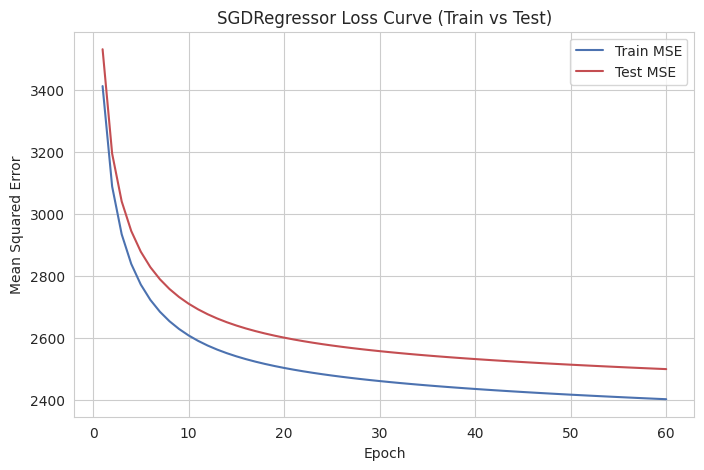

In [ ]:
sgd = SGDRegressor(
    loss="squared_error",
    penalty="l2",
    alpha=0.0001,
    learning_rate="invscaling",
    eta0=0.001,
    random_state=42,
)

N_EPOCHS = 60
train_losses, test_losses = [], []
for epoch in range(N_EPOCHS):
    sgd.partial_fit(X_train_t, y_train)
    train_pred = sgd.predict(X_train_t)
    test_pred = sgd.predict(X_test_t)
    train_losses.append(mean_squared_error(y_train, train_pred))
    test_losses.append(mean_squared_error(y_test, test_pred))

plt.figure(figsize=(8,5))
plt.plot(range(1, N_EPOCHS+1), train_losses, label="Train MSE", color="#4C72B0")
plt.plot(range(1, N_EPOCHS+1), test_losses, label="Test MSE", color="#C44E52")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("SGDRegressor Loss Curve (Train vs Test)")
plt.legend()
plt.show()

sgd_pred_test = sgd.predict(X_test_t)
sgd_pred_train = sgd.predict(X_train_t)


In [ ]:
lin = LinearRegression()
lin.fit(X_train_t, y_train)
lin_pred_test = lin.predict(X_test_t)
lin_pred_train = lin.predict(X_train_t)



In [ ]:
rf = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train_t, y_train)
rf_pred_test = rf.predict(X_test_t)
rf_pred_train = rf.predict(X_train_t)


In [ ]:
dt = DecisionTreeRegressor(max_depth=15, min_samples_leaf=3, random_state=42)
dt.fit(X_train_t, y_train)
dt_pred_test = dt.predict(X_test_t)
dt_pred_train = dt.predict(X_train_t)



In [ ]:
def report(name, y_tr, tr_pred, y_te, te_pred):
    return {
        "model": name,
        "train_RMSE": np.sqrt(mean_squared_error(y_tr, tr_pred)),
        "test_RMSE": np.sqrt(mean_squared_error(y_te, te_pred)),
        "train_MAE": mean_absolute_error(y_tr, tr_pred),
        "test_MAE": mean_absolute_error(y_te, te_pred),
        "train_R2": r2_score(y_tr, tr_pred),
        "test_R2": r2_score(y_te, te_pred),
    }

results = pd.DataFrame([
    report("SGDRegressor (SGD)", y_train, sgd_pred_train, y_test, sgd_pred_test),
    report("LinearRegression (OLS)", y_train, lin_pred_train, y_test, lin_pred_test),
    report("RandomForestRegressor", y_train, rf_pred_train, y_test, rf_pred_test),
    report("DecisionTreeRegressor", y_train, dt_pred_train, y_test, dt_pred_test),
]).round(3)


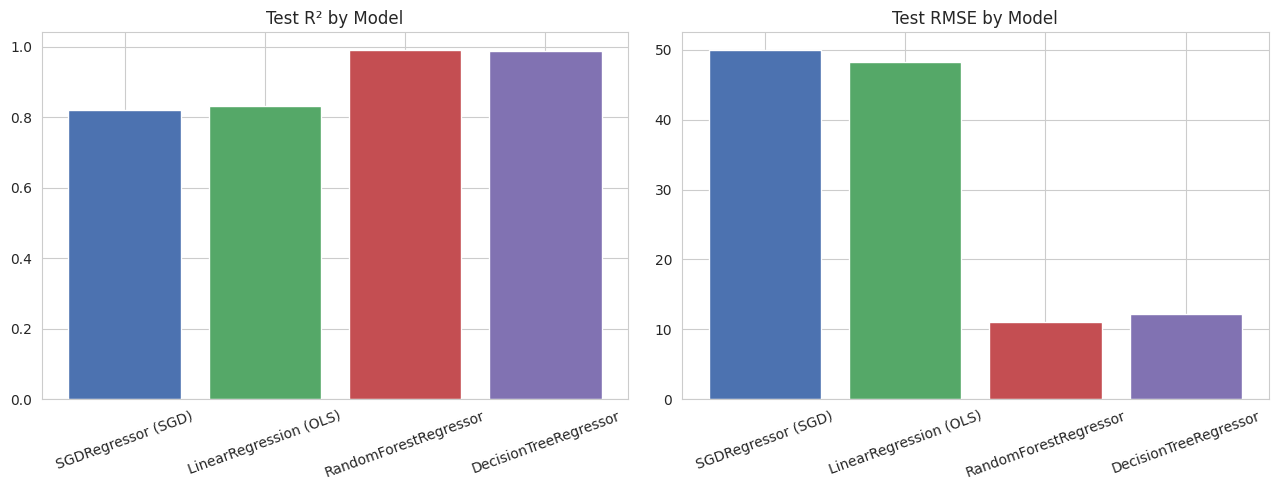

In [ ]:
MODEL_COLORS = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]
fig, axes = plt.subplots(1, 2, figsize=(13,5))
axes[0].bar(results["model"], results["test_R2"], color=MODEL_COLORS)
axes[0].set_title("Test R² by Model"); axes[0].tick_params(axis="x", rotation=20)
axes[1].bar(results["model"], results["test_RMSE"], color=MODEL_COLORS)
axes[1].set_title("Test RMSE by Model"); axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


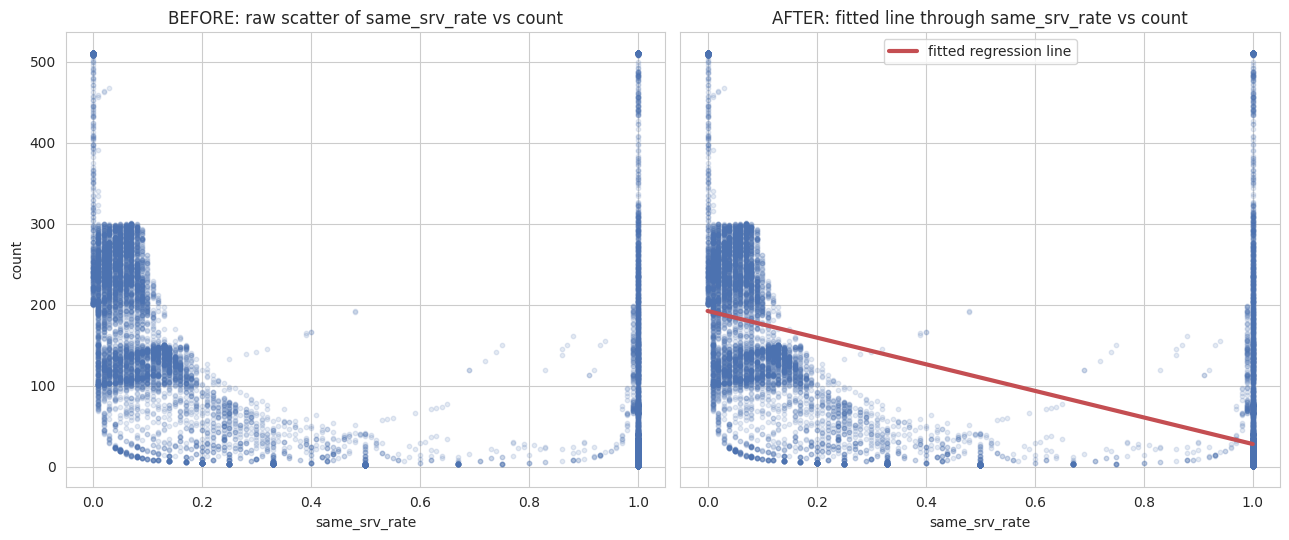

count = -164.29 * same_srv_rate + 192.50


In [ ]:
feat = "same_srv_rate"
x_vis = X_train[feat].values.reshape(-1, 1)
y_vis = y_train.values

simple_lr = LinearRegression().fit(x_vis, y_vis)
x_line = np.linspace(x_vis.min(), x_vis.max(), 100).reshape(-1, 1)
y_line = simple_lr.predict(x_line)

fig, axes = plt.subplots(1, 2, figsize=(13,5.5), sharey=True)
axes[0].scatter(x_vis, y_vis, alpha=0.15, s=10, color="#4C72B0")
axes[0].set_title(f"BEFORE: raw scatter of {feat} vs count")
axes[0].set_xlabel(feat); axes[0].set_ylabel("count")

axes[1].scatter(x_vis, y_vis, alpha=0.15, s=10, color="#4C72B0")
axes[1].plot(x_line, y_line, color="#C44E52", linewidth=3, label="fitted regression line")
axes[1].set_title(f"AFTER: fitted line through {feat} vs count")
axes[1].set_xlabel(feat); axes[1].legend()
plt.tight_layout()
plt.show()

print(f"count = {simple_lr.coef_[0]:.2f} * {feat} + {simple_lr.intercept_:.2f}")


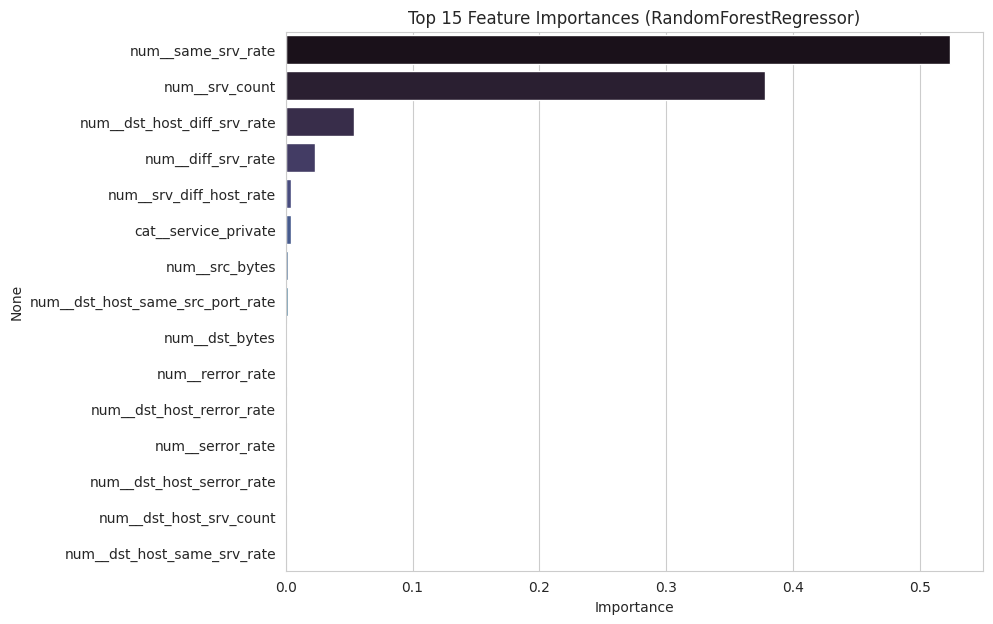

,0
num__same_srv_rate,0.523469
num__srv_count,0.377496
num__dst_host_diff_srv_rate,0.053941
num__diff_srv_rate,0.022769
num__srv_diff_host_rate,0.004493
cat__service_private,0.003971
num__src_bytes,0.002211
num__dst_host_same_src_port_rate,0.002181
num__dst_bytes,0.001334
num__rerror_rate,0.001290


In [ ]:
feature_names = preprocessor.get_feature_names_out()
importances = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)
top15 = importances.head(15)

plt.figure(figsize=(9,7))
sns.barplot(x=top15.values, y=top15.index, palette="mako")
plt.title("Top 15 Feature Importances (RandomForestRegressor)")
plt.xlabel("Importance")
plt.show()

top15

In [ ]:
sample_idx = 0
one_row = X_test.iloc[[sample_idx]]
one_row_transformed = preprocessor.transform(one_row)
if hasattr(one_row_transformed, "toarray"):
    one_row_transformed = one_row_transformed.toarray()

one_row_pred = rf.predict(one_row_transformed)[0]
one_row_true = y_test.iloc[sample_idx]

print("Input row (raw features):")
display(one_row)
print(f"\nTrue count:      {one_row_true}")
print(f"Predicted count: {one_row_pred:.2f}")
print(f"Absolute error:  {abs(one_row_true - one_row_pred):.2f}")


Input row (raw features):


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
19064,0,icmp,ecr_i,SF,1032,0,0,0,0,0,...,255,255,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0



True count:      13
Predicted count: 13.03
Absolute error:  0.03


In [ ]:
best_row = results.loc[results["test_R2"].idxmax()]
best_name = best_row["model"]
print(f"Best model by test R2: {best_name}  (R2={best_row['test_R2']}, RMSE={best_row['test_RMSE']})")

best_model_obj = {
    "SGDRegressor (SGD)": sgd,
    "LinearRegression (OLS)": lin,
    "RandomForestRegressor": rf,
    "DecisionTreeRegressor": dt,
}[best_name]

final_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", best_model_obj),
])

joblib.dump(final_pipeline, "best_model.joblib")
joblib.dump(
    {"target": TARGET, "categorical": CATEGORICAL, "numeric": NUMERIC,
     "dropped_cols": ZERO_VAR_COLS + ["class"], "best_model_name": best_name},
    "model_metadata.joblib",
)
print("Saved best_model.joblib and model_metadata.joblib")

try:
    from google.colab import files
    files.download("best_model.joblib")
    files.download("model_metadata.joblib")
except ImportError:
    pass


Best model by test R2: RandomForestRegressor  (R2=0.991, RMSE=11.107)
Saved best_model.joblib and model_metadata.joblib


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
candidate_sets = {
    "Top 2 (same_srv_rate, srv_count)": ["same_srv_rate", "srv_count"],
    "Top 4 (+ dst_host_diff_srv_rate, diff_srv_rate)": [
        "same_srv_rate", "srv_count", "dst_host_diff_srv_rate", "diff_srv_rate"
    ],
    "Top 6 (+ service, src_bytes)": [
        "same_srv_rate", "srv_count", "dst_host_diff_srv_rate", "diff_srv_rate",
        "service", "src_bytes",
    ],
}

simplification_results = []
for set_name, feats in candidate_sets.items():
    cat_feats = [f for f in feats if f in CATEGORICAL]
    num_feats = [f for f in feats if f not in CATEGORICAL]
    X_sub = df[feats]
    X_sub_train, X_sub_test, y_sub_train, y_sub_test = train_test_split(
        X_sub, y, test_size=0.2, random_state=42
    )
    sub_pre = ColumnTransformer(transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_feats),
        ("num", StandardScaler(), num_feats),
    ])
    sub_rf = RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
    sub_pipeline = Pipeline([("preprocessor", sub_pre), ("regressor", sub_rf)])
    sub_pipeline.fit(X_sub_train, y_sub_train)
    sub_pred = sub_pipeline.predict(X_sub_test)
    sub_r2 = r2_score(y_sub_test, sub_pred)
    sub_rmse = np.sqrt(mean_squared_error(y_sub_test, sub_pred))
    simplification_results.append((set_name, len(feats), sub_r2, sub_rmse, sub_pipeline))
    print(f"{set_name}: n_features={len(feats)}  R2={sub_r2:.4f}  RMSE={sub_rmse:.2f}")

print(f"Full 38-feature model (reference): R2={best_row['test_R2']:.4f}  RMSE={best_row['test_RMSE']:.2f}")


Top 2 (same_srv_rate, srv_count): n_features=2  R2=0.9541  RMSE=25.20
Top 4 (+ dst_host_diff_srv_rate, diff_srv_rate): n_features=4  R2=0.9826  RMSE=15.51
Top 6 (+ service, src_bytes): n_features=6  R2=0.9844  RMSE=14.70
Full 38-feature model (reference): R2=0.9910  RMSE=11.11


In [ ]:
DEPLOY_FEATURES = ["same_srv_rate", "srv_count", "dst_host_diff_srv_rate", "diff_srv_rate"]
deploy_result = next(r for r in simplification_results if r[1] == len(DEPLOY_FEATURES))
_, _, deploy_r2, deploy_rmse, deploy_pipeline = deploy_result

print(f"Top-4 experiment: RandomForestRegressor on {DEPLOY_FEATURES}")
print(f"Test R2={deploy_r2:.4f}  RMSE={deploy_rmse:.2f}  (vs full 38-feature model R2={best_row['test_R2']:.4f})")
print("(Not saved/deployed -- kept as an exploratory reference; the full 38-feature model above is what's deployed.)")


Top-4 experiment: RandomForestRegressor on ['same_srv_rate', 'srv_count', 'dst_host_diff_srv_rate', 'diff_srv_rate']
Test R2=0.9826  RMSE=15.51  (vs full 38-feature model R2=0.9910)
(Not saved/deployed -- kept as an exploratory reference; the full 38-feature model above is what's deployed.)


In [ ]:
test_df = pd.read_csv("Test_data.csv")

# apply the same cleaning used in training (drop the same zero-variance cols;
# Test_data.csv never had `class` to begin with)
test_df_clean = test_df.drop(columns=[c for c in ZERO_VAR_COLS if c in test_df.columns])

loaded_pipeline = joblib.load("best_model.joblib")
loaded_meta = joblib.load("model_metadata.joblib")

X_new = test_df_clean[loaded_meta["categorical"] + loaded_meta["numeric"]]
predictions = loaded_pipeline.predict(X_new)

output = test_df.copy()
output["predicted_count"] = predictions
output.to_csv("predictions_for_next_task.csv", index=False)

print(f"Model used: {loaded_meta['best_model_name']}")
print(output[["predicted_count"]].describe())
output.head()


Model used: RandomForestRegressor
       predicted_count
count     22544.000000
mean         79.448739
std         129.627107
min           1.000000
25%           1.999857
50%           9.012659
75%         120.431896
max         511.000000


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,predicted_count
0,0,tcp,private,REJ,0,0,0,0,0,0,...,10,0.04,0.06,0.00,0.00,0.0,0.0,1.00,1.00,264.928999
1,0,tcp,private,REJ,0,0,0,0,0,0,...,1,0.00,0.06,0.00,0.00,0.0,0.0,1.00,1.00,127.872202
2,2,tcp,ftp_data,SF,12983,0,0,0,0,0,...,86,0.61,0.04,0.61,0.02,0.0,0.0,0.00,0.00,1.000000
3,0,icmp,eco_i,SF,20,0,0,0,0,0,...,57,1.00,0.00,1.00,0.28,0.0,0.0,0.00,0.00,7.196667
4,1,tcp,telnet,RSTO,0,15,0,0,0,0,...,86,0.31,0.17,0.03,0.02,0.0,0.0,0.83,0.71,1.142727


In [ ]:
try:
    from google.colab import files
    files.download("predictions_for_next_task.csv")
except ImportError:
    pass

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>